In [1]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime
import statsmodels.api as sm
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA

%matplotlib inline

In [4]:
df = pd.read_csv('dataset.csv')
df.head()

,SystemCodeNumber,Capacity,Occupancy,LastUpdated
0,BHMBCCMKT01,577,61,2016-10-04 07:59:42
1,BHMBCCMKT01,577,64,2016-10-04 08:25:42
2,BHMBCCMKT01,577,80,2016-10-04 08:59:42
3,BHMBCCMKT01,577,107,2016-10-04 09:32:46
4,BHMBCCMKT01,577,150,2016-10-04 09:59:48


In [40]:
df['LastUpdated'] = pd.to_datetime(df['LastUpdated'])

In [12]:
segregated_lots = {lot_id: group_df for lot_id, group_df in df.groupby('SystemCodeNumber')}

In [41]:
one_lot_df = segregated_lots['BHMBCCMKT01']
one_lot_df['LastUpdated'] = pd.to_datetime(one_lot_df['LastUpdated'])
one_lot_df = one_lot_df.set_index('LastUpdated')

In [42]:
one_lot_df

,SystemCodeNumber,Capacity,Occupancy
LastUpdated,,,
2016-10-04 07:59:42,BHMBCCMKT01,577,61
2016-10-04 08:25:42,BHMBCCMKT01,577,64
2016-10-04 08:59:42,BHMBCCMKT01,577,80
2016-10-04 09:32:46,BHMBCCMKT01,577,107
2016-10-04 09:59:48,BHMBCCMKT01,577,150
...,...,...,...
2016-12-19 14:30:33,BHMBCCMKT01,577,309
2016-12-19 15:03:34,BHMBCCMKT01,577,300
2016-12-19 15:29:33,BHMBCCMKT01,577,274


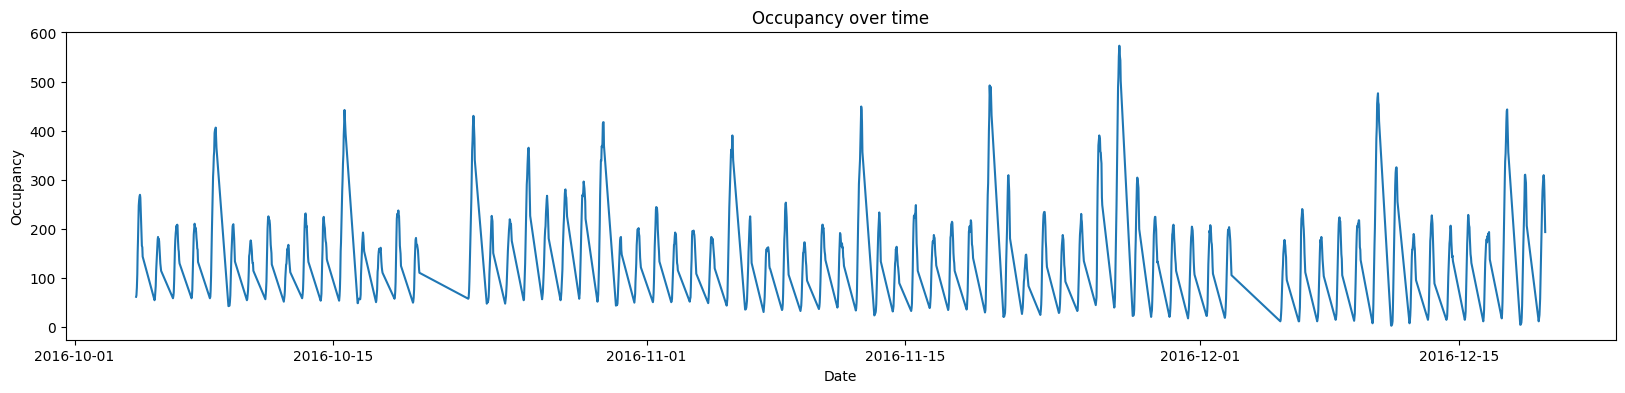

In [43]:

plt.figure(figsize=(20,4))
plt.plot(one_lot_df.index, one_lot_df['Occupancy'])
plt.xlabel('Date')
plt.ylabel('Occupancy')
plt.title('Occupancy over time')
plt.show()


In [44]:


# Apply the new processing steps to this single lot

def process_lot_data(lot_df):
    """
    Applies time series processing to a single parking lot's DataFrame.

    1. Sets 'LastUpdated' as the index.
    2. Resamples data to a regular hourly frequency ('H'), taking the mean.
    3. Interpolates any missing values that result from resampling.
    4. Engineers new time-based features (hour, day of week, weekend).
    """
    # Create a copy to avoid modifying the original data
    df = lot_df.copy()


    # Sort the index to ensure data is in chronological order
    df = df.sort_index()

    # 2. Resample the data to a regular hourly ('H') frequency
    # We take the 'mean' of 'Occupancy' for all readings within that hour.
    # This standardizes the time steps.
    df_resampled = df['Occupancy'].resample('H').mean()

    # 3. Interpolate missing values (e.g., if an hour had no readings)
    # The 'time' method fills in missing values based on their time-based
    # distance between known points.
    df_resampled = df_resampled.interpolate(method='time')

    # Convert the resampled Series back to a DataFrame
    df_processed = df_resampled.to_frame()

    # --- 4. Feature Engineering ("day of week step") ---

    # Extract 'hour_of_day' (0-23)
    df_processed['hour_of_day'] = df_processed.index.hour

    # Extract 'day_of_week' (Monday=0, Sunday=6)
    df_processed['day_of_week'] = df_processed.index.dayofweek

    # Create a binary 'is_weekend' feature (1 for Sat/Sun, 0 for Weekday)
    df_processed['is_weekend'] = (df_processed['day_of_week'] >= 5).astype(int)

    # Optional: Drop rows with NaN values that couldn't be interpolated (e.g., at the very start)
    df_processed = df_processed.dropna()

    return df_processed

# --- How to use this code ---

# Load the original data and create the segregated_lots dictionary
# (This code is from the previous step, included for


# Select the lot you plotted ('BHMBCCMKT01') from the dictionary


# 'processed_lot_data' is now ready for modeling.
# It has a regular hourly index, interpolated 'Occupancy',
# and the new features you requested.

# To see the result:
processed_lot_data = process_lot_data(one_lot_df)
print(processed_lot_data)

                     Occupancy  hour_of_day  day_of_week  is_weekend
LastUpdated                                                         
2016-10-04 07:00:00       61.0            7            1           0
2016-10-04 08:00:00       72.0            8            1           0
2016-10-04 09:00:00      128.5            9            1           0
2016-10-04 10:00:00      198.0           10            1           0
2016-10-04 11:00:00      253.0           11            1           0
...                        ...          ...          ...         ...
2016-12-19 12:00:00      232.5           12            0           0
2016-12-19 13:00:00      284.0           13            0           0
2016-12-19 14:00:00      307.0           14            0           0
2016-12-19 15:00:00      287.0           15            0           0
2016-12-19 16:00:00      211.5           16            0           0

[1834 rows x 4 columns]


/tmp/ipython-input-3338847634.py:22: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_resampled = df['Occupancy'].resample('H').mean()


[Text(0, 0, 'Monday'),
 Text(1, 0, 'Tuesday'),
 Text(2, 0, 'Wednesday'),
 Text(3, 0, 'Thursday'),
 Text(4, 0, 'Friday'),
 Text(5, 0, 'Saturday'),
 Text(6, 0, 'Sunday')]

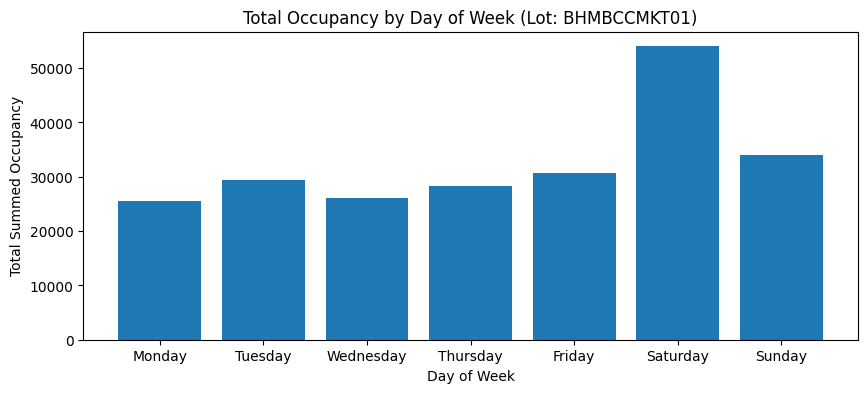

In [22]:
import matplotlib.pyplot as plt
import numpy as np

# --- Code for Bar Plot ---

# Aggregate the data: Group by the 'day_of_week' and sum 'Occupancy'
daily_total_occupancy = processed_lot_data.groupby('day_of_week').sum()['Occupancy']

# Start the plot
plt.figure(figsize=(10, 4))
ax = plt.gca()

# Create the bar chart using the aggregated data
plt.bar(daily_total_occupancy.index, daily_total_occupancy.values)

# Set labels and title
ax.set_xlabel('Day of Week')
ax.set_ylabel('Total Summed Occupancy')
ax.set_title('Total Occupancy by Day of Week (Lot: BHMBCCMKT01)')

# Set user-friendly x-axis tick labels
day_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
ax.set_xticks(range(7))
ax.set_xticklabels(day_names)

# Save the figure
# plt.savefig('occupancy_by_day_of_week.png')

In [45]:
import pandas as pd
from statsmodels.tsa.stattools import adfuller

def test_stationarity(ts):
    """
    Runs the Augmented Dickey-Fuller test to check for stationarity.
    'ts' should be a pandas Series (like our 'Occupancy' column).
    """
    stats = ['Test Statistic','p-value','Lags','Observations']


    df_test = adfuller(ts, autolag='AIC')

    df_results = pd.Series(df_test[0:4], index=stats)
    for key,value in df_test[4].items():
        df_results['Critical Value (%s)'%key] = value
    print(df_results)

# --- How to run the test ---
# (Assuming 'processed_lot_data' is your DataFrame from the previous step)
#
test_stationarity(processed_lot_data['Occupancy'])

Test Statistic         -7.270355e+00
p-value                 1.594393e-10
Lags                    2.500000e+01
Observations            1.808000e+03
Critical Value (1%)    -3.433972e+00
Critical Value (5%)    -2.863140e+00
Critical Value (10%)   -2.567622e+00
dtype: float64


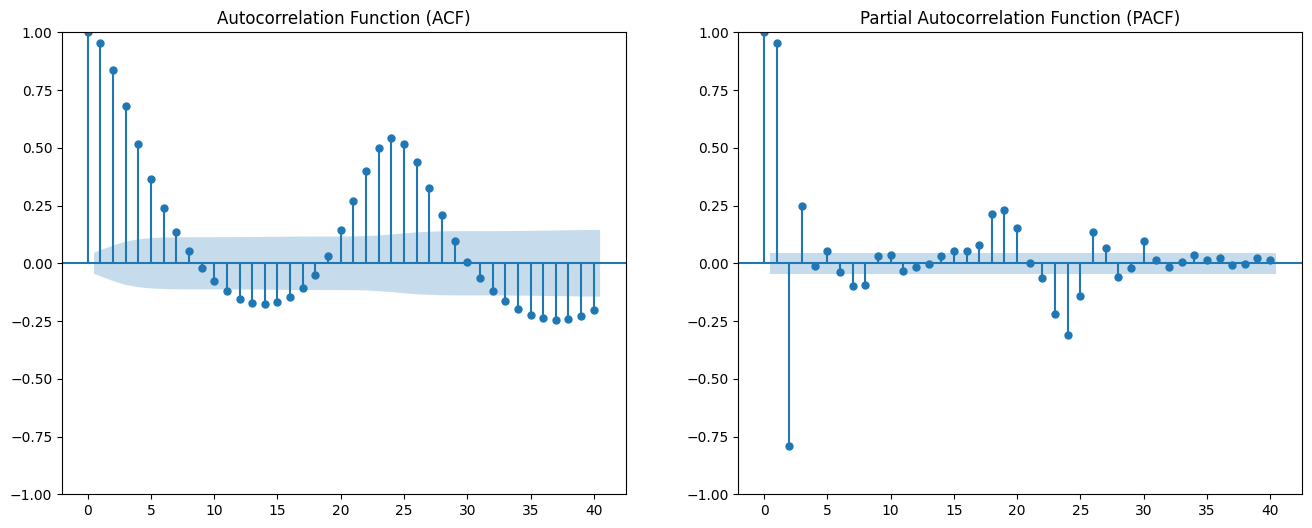

In [46]:
#the data is already statorinary
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# --- Code to plot ACF and PACF ---

# (Assuming 'processed_lot_data' is your DataFrame from the previous step)
# We will use the 'Occupancy' column, which the ADFuller test
# showed to be stationary.

# Set up the figure and subplots
# We create one figure with two plots side-by-side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot the ACF (Autocorrelation Function)
# This helps identify the 'q' parameter (Moving Average order)
plot_acf(processed_lot_data['Occupancy'], ax=ax1, lags=40)
ax1.set_title('Autocorrelation Function (ACF)')

# Plot the PACF (Partial Autocorrelation Function)
# This helps identify the 'p' parameter (Autoregressive order)
plot_pacf(processed_lot_data['Occupancy'], ax=ax2, lags=40)
ax2.set_title('Partial Autocorrelation Function (PACF)')

# Display the plots
plt.show()

# Save the figure
# fig.savefig('acf_pacf_plots.png')

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose

result = seasonal_decompose(processed_lot_data['Occupancy'], model='additive', period=24)
result.plot()
plt.show()


In [35]:
# --- 1. Train-Test Split ---

# We will use the features we engineered ('hour_of_day', 'day_of_week', 'is_weekend')
# as exogenous variables (X) to help predict the 'Occupancy' (y).
features = ['hour_of_day', 'day_of_week', 'is_weekend']
target = 'Occupancy'

# Determine the split point (80% of the data)
split_point = int(len(processed_lot_data) * 0.8)

# Create training sets (the first 80%)
# y_train is the 'Occupancy' we want to predict
y_train = processed_lot_data[target].iloc[:split_point]
# X_train are the features for the training data
X_train = processed_lot_data[features].iloc[:split_point]

# Create test sets (the last 20%)
# y_test is the 'Occupancy' we will test against
y_test = processed_lot_data[target].iloc[split_point:]
# X_test are the features for the test data
X_test = processed_lot_data[features].iloc[split_point:]

print(f"Training data points: {len(y_train)}")
print(f"Test data points: {len(y_test)}")

Training data points: 1467
Test data points: 367


In [47]:
one_lot_df

,SystemCodeNumber,Capacity,Occupancy
LastUpdated,,,
2016-10-04 07:59:42,BHMBCCMKT01,577,61
2016-10-04 08:25:42,BHMBCCMKT01,577,64
2016-10-04 08:59:42,BHMBCCMKT01,577,80
2016-10-04 09:32:46,BHMBCCMKT01,577,107
2016-10-04 09:59:48,BHMBCCMKT01,577,150
...,...,...,...
2016-12-19 14:30:33,BHMBCCMKT01,577,309
2016-12-19 15:03:34,BHMBCCMKT01,577,300
2016-12-19 15:29:33,BHMBCCMKT01,577,274


In [48]:
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# choose target series
y = processed_lot_data['Occupancy']

# simple 80/20 split by time
split = int(len(y)*0.8)
y_train, y_test = y.iloc[:split], y.iloc[split:]

# Fit a simple ARIMA(1,0,0) as test
model = ARIMA(y_train, order=(1,0,0))
res = model.fit()
# one-step forecast on test range (recursive)
preds = res.predict(start=y_test.index[0], end=y_test.index[-1])

mae = mean_absolute_error(y_test, preds)
rmse = np.sqrt(mean_squared_error(y_test, preds))
print("MAE:", mae, "RMSE:", rmse)
print(res.summary())


MAE: 71.89971960208918 RMSE: 90.05159945602533
                               SARIMAX Results                                
Dep. Variable:              Occupancy   No. Observations:                 1467
Model:                 ARIMA(1, 0, 0)   Log Likelihood               -6786.127
Date:                Mon, 20 Oct 2025   AIC                          13578.255
Time:                        07:09:22   BIC                          13594.128
Sample:                    10-04-2016   HQIC                         13584.174
                         - 12-04-2016                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        127.1598     20.352      6.248      0.000      87.270     167.049
ar.L1          0.9536      0.006    149.279      0.000       0.941       0.966
sigma

In [52]:
import lightgbm as lgb

# Build lag features
df = processed_lot_data.copy()
for lag in [1,2,3,24,48]:
    df[f'lag_{lag}'] = df['Occupancy'].shift(lag)
df = df.dropna()

features = ['lag_1','lag_2','lag_3','lag_24','hour_of_day','day_of_week','is_weekend']
target = 'Occupancy'
split = int(len(df)*0.8)
train, test = df.iloc[:split], df.iloc[split:]

train_data = lgb.Dataset(train[features], label=train[target])
params = {'objective':'regression', 'metric':'l2'}
bst = lgb.train(params, train_data, num_boost_round=200)
preds_lgm = bst.predict(test[features])
print("MAE:", mean_absolute_error(test[target], preds))


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.015310 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1053
[LightGBM] [Info] Number of data points in the train set: 1428, number of used features: 7
[LightGBM] [Info] Start training from score 126.905621
MAE: 7.687282133193884


In [53]:
from sklearn.metrics import mean_squared_error
import numpy as np
rmse = np.sqrt(mean_squared_error(test[target], preds_lgm))
print("RMSE:", rmse)


RMSE: 12.068329251718232


ValueError: x and y must have same first dimension, but have shapes (367,) and (358,)

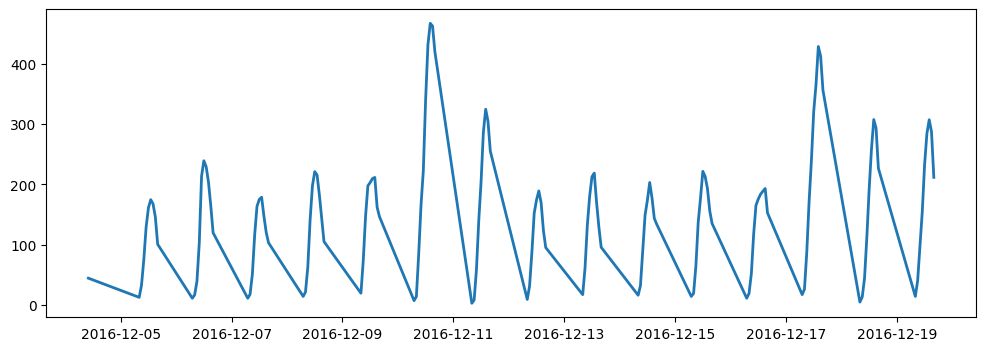

In [54]:
plt.figure(figsize=(12,4))
plt.plot(y_test.index, y_test, label='Actual', linewidth=2)
plt.plot(y_test.index, preds_lgm, label='LightGBM', alpha=0.8)
plt.legend()
plt.title('Actual vs Predicted Occupancy')
plt.show()

MAE: 7.687282133193884 RMSE: 12.068329251718232


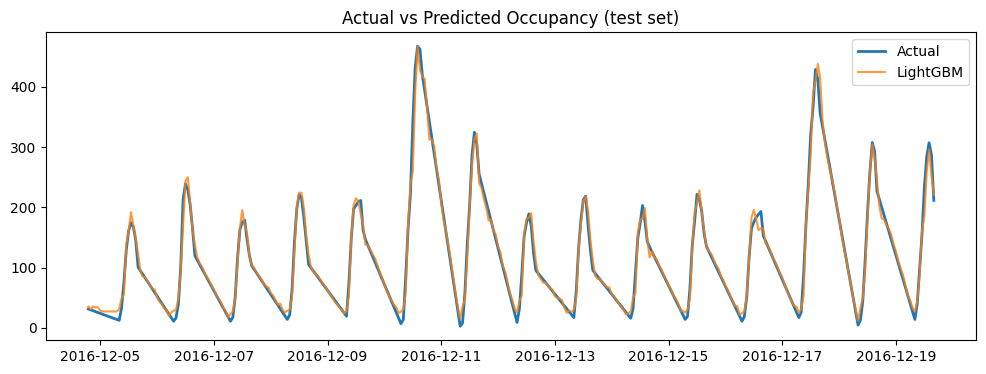

In [55]:
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Build lag features
df = processed_lot_data.copy()
for lag in [1,2,3,24,48]:
    df[f'lag_{lag}'] = df['Occupancy'].shift(lag)

# Drop rows with NA introduced by shifting
df = df.dropna()

features = ['lag_1','lag_2','lag_3','lag_24','hour_of_day','day_of_week','is_weekend']
target = 'Occupancy'

# Time-based split on the SAME df (so indices align)
split = int(len(df)*0.8)
train, test = df.iloc[:split], df.iloc[split:]

# Train LightGBM
train_data = lgb.Dataset(train[features], label=train[target])
params = {'objective':'regression', 'metric':'l2', 'verbosity': -1, 'seed': 42}
bst = lgb.train(params, train_data, num_boost_round=200)

# Predict
preds_lgm = bst.predict(test[features])

# Wrap preds into a Series with the same index as test for safe plotting/alignment
preds_series = pd.Series(preds_lgm, index=test.index)

# Metrics (make sure we compare test[target] vs preds_series)
mae = mean_absolute_error(test[target], preds_series)
rmse = np.sqrt(mean_squared_error(test[target], preds_series))
print("MAE:", mae, "RMSE:", rmse)

# Plot actual vs predicted using the same index
plt.figure(figsize=(12,4))
plt.plot(test.index, test[target], label='Actual', linewidth=2)
plt.plot(preds_series.index, preds_series.values, label='LightGBM', alpha=0.8)
plt.legend()
plt.title('Actual vs Predicted Occupancy (test set)')
plt.show()


In [56]:
preds_train = bst.predict(train[features])
print("Train MAE:", mean_absolute_error(train[target], preds_train))
print("Test MAE:", mean_absolute_error(test[target], preds_lgm))


Train MAE: 2.487458148346349
Test MAE: 7.687282133193884


Direct next-6h predictions:
 2016-12-19 17:00:00    225.920682
2016-12-19 18:00:00    201.120620
2016-12-19 19:00:00    182.258414
2016-12-19 20:00:00    157.278988
2016-12-19 21:00:00    167.100741
2016-12-19 22:00:00    156.216180
dtype: float64
Recursive next-6h predictions:
 2016-12-19 17:00:00    213.135202
2016-12-19 18:00:00    191.235529
2016-12-19 19:00:00    172.018754
2016-12-19 20:00:00    158.559678
2016-12-19 21:00:00    142.064031
2016-12-19 22:00:00    126.387415
dtype: float64
Rolling direct eval (H=6) summary: {1: {'MAE_mean': np.float64(16.363211599829448), 'MAE_std': np.float64(9.887543399073323), 'RMSE_mean': np.float64(33.14542573830608)}, 2: {'MAE_mean': np.float64(21.509631873138122), 'MAE_std': np.float64(15.255531411320188), 'RMSE_mean': np.float64(54.66560059392341)}, 3: {'MAE_mean': np.float64(26.304926998173844), 'MAE_std': np.float64(19.256419774451334), 'RMSE_mean': np.float64(69.06453664652547)}, 4: {'MAE_mean': np.float64(28.661974766342183), 'MAE_std':

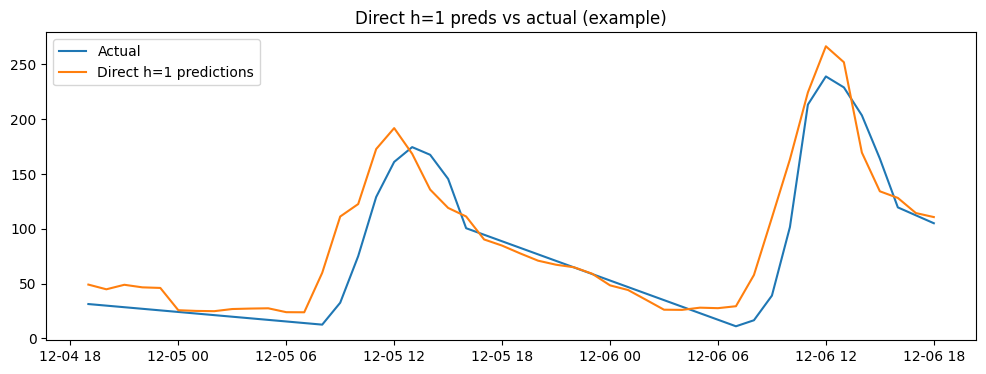

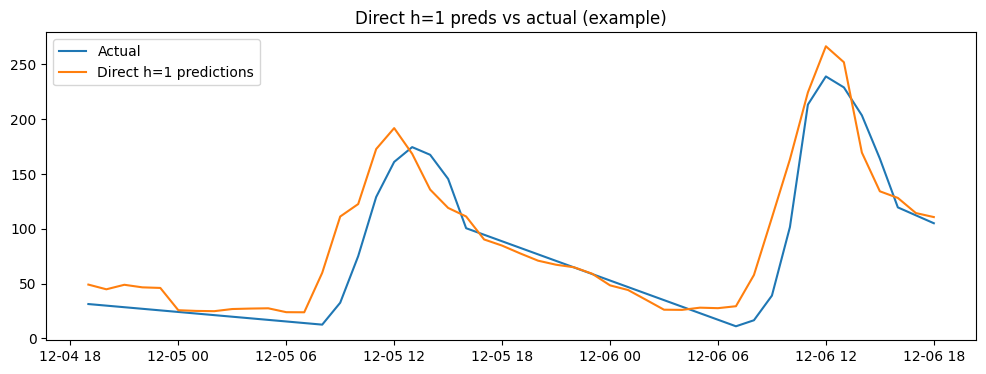

In [59]:
# Multi-step forecasting: direct & recursive + rolling evaluation (LightGBM)
import numpy as np
import pandas as pd
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
from tqdm import trange

# ---------------------------
# Helper: create lag features
# ---------------------------
def make_lag_features(df, lags):
    df = df.copy()
    for lag in lags:
        df[f'lag_{lag}'] = df['Occupancy'].shift(lag)
    return df

# ---------------------------
# Direct multi-step trainer
# Train a separate model for each horizon 1..H
# ---------------------------
def train_direct_models(df, features, target, max_horizon, params=None, num_boost_round=200):
    models = {}
    params = params or {'objective':'regression', 'metric':'l2', 'verbosity': -1, 'seed': 42}
    for h in range(1, max_horizon+1):
        # For horizon h, target is Occupancy shifted -h (i.e., future value)
        df_h = df.copy()
        df_h['target_h'] = df_h[target].shift(-h)
        df_h = df_h.dropna()
        X = df_h[features]
        y = df_h['target_h']
        train_data = lgb.Dataset(X, label=y)
        models[h] = lgb.train(params, train_data, num_boost_round=num_boost_round)
    return models

# ---------------------------
# Recursive 1-step trainer
# ---------------------------
def train_recursive_model(df, features, target, params=None, num_boost_round=200):
    params = params or {'objective':'regression', 'metric':'l2', 'verbosity': -1, 'seed': 42}
    df_r = df.dropna()
    X = df_r[features]
    y = df_r[target]
    train_data = lgb.Dataset(X, label=y)
    model = lgb.train(params, train_data, num_boost_round=num_boost_round)
    return model

# ---------------------------
# Predict direct: given trained models dict, predict horizons 1..H for a test index block
# df_block must include lag features and future calendar features for horizons
# ---------------------------
def predict_direct(models, df_block, features):
    preds = {}
    for h, model in models.items():
        # For direct model h, the model expects features at t (lags etc) to predict t+h
        # We predict for all rows where target t+h exists in df_block (i.e., df_block.dropna() alignment)
        X = df_block[features].dropna()
        preds[h] = pd.Series(model.predict(X), index=X.index)
    return preds

# ---------------------------
# Predict recursive: iteratively predict 1-step and append to lags
# df_start is the dataframe containing the most recent observations to start predicting from
# horizon H: we will return series of length H with index built from df_start.index[0] + 1..H hours
# ---------------------------
def predict_recursive(model, df_start, features, max_horizon):
    df_work = df_start.copy()
    preds = []
    # ensure sorted by time ascending
    for h in range(1, max_horizon+1):
        X = df_work[features].iloc[[-1]]  # latest row features
        yhat = float(model.predict(X)[0])
        preds.append(yhat)
        # append predicted occupancy as a new row (with index shifted by +1 hour)
        next_index = df_work.index[-1] + pd.Timedelta(hours=1)
        # build next row: shift lag columns, set new occupancy as yhat, and compute calendar features
        new_row = {}
        # copy existing row structure but shift lags
        for col in df_work.columns:
            if col.startswith('lag_'):
                # shift: new lag_k = previous occupancy at t - k + 1, so get from last row or predicted
                lag_k = int(col.split('_')[1])
                if lag_k == 1:
                    new_row[col] = yhat
                else:
                    prev_val = df_work.iloc[-1].get(f'lag_{lag_k-1}', np.nan)
                    new_row[col] = prev_val
            elif col == 'Occupancy':
                new_row[col] = yhat
            # for calendar features, compute from next_index
        # calendar features
        new_row['hour_of_day'] = next_index.hour
        new_row['day_of_week'] = next_index.dayofweek
        new_row['is_weekend'] = int(next_index.dayofweek >= 5)
        # create DataFrame row and append
        new_df_row = pd.DataFrame(new_row, index=[next_index])
        # ensure columns align (missing columns filled with NaN)
        for c in df_work.columns:
            if c not in new_df_row.columns:
                new_df_row[c] = np.nan
        new_df_row = new_df_row[df_work.columns]  # order columns
        df_work = pd.concat([df_work, new_df_row])
    # return series with proper future index
    future_index = [df_start.index[-1] + pd.Timedelta(hours=i) for i in range(1, max_horizon+1)]
    return pd.Series(preds, index=future_index)

# ---------------------------
# Rolling-origin evaluation for multi-step
# - strategy: expanding train window, fixed horizon H evaluation, step=step_hours
# - mode: 'direct' or 'recursive'
# ---------------------------
def rolling_multi_eval(df, features, target, max_horizon=24, step=24, initial_train_hours=7*24, mode='direct', params=None, num_boost_round=200):
    params = params or {'objective':'regression', 'metric':'l2', 'verbosity': -1, 'seed': 42}
    n = len(df)
    metrics = {h: [] for h in range(1, max_horizon+1)}
    fold_starts = range(initial_train_hours, n - max_horizon, step)
    for fold_start in fold_starts:
        train = df.iloc[:fold_start].dropna()
        test = df.iloc[fold_start: fold_start + max_horizon + step].copy()
        if mode == 'direct':
            models = train_direct_models(train, features, target, max_horizon, params=params, num_boost_round=num_boost_round)
            test_block = test.copy().dropna()
            preds_dict = predict_direct(models, test_block, features)
            for h in range(1, max_horizon+1):
                pred_series = preds_dict[h]
                true_index = pred_series.index + pd.Timedelta(hours=h)
                true_vals = df[target].reindex(true_index)
                mask = ~true_vals.isna()
                if mask.sum() == 0:
                    continue
                mae = mean_absolute_error(true_vals[mask], pred_series[mask.values])
                mse = np.mean((true_vals[mask] - pred_series[mask.values])**2)  # MSE for this fold & horizon
                metrics[h].append((mae, mse))
        else:  # recursive
            rec_model = train_recursive_model(train, features, target, params=params, num_boost_round=num_boost_round)
            seed_df = train.copy().iloc[-max(48, 24):]
            rec_preds = predict_recursive(rec_model, seed_df, features, max_horizon)
            for h in range(1, max_horizon+1):
                true_val = df[target].reindex([rec_preds.index[h-1]]).values
                if np.isnan(true_val):
                    continue
                mae = abs(true_val[0] - rec_preds.iloc[h-1])
                metrics[h].append((mae, mae**2))

    summary = {}
    for h, vals in metrics.items():
        if not vals:
            continue
        maes = [v[0] for v in vals]
        mses = [v[1] for v in vals]
        summary[h] = {'MAE_mean': np.mean(maes), 'MAE_std': np.std(maes), 'RMSE_mean': np.sqrt(np.mean(mses))}
    return summary
# ---------------------------
# Example usage on your processed_lot_data
# ---------------------------
# 1) Build lag features on processed_lot_data (ensure enough lags - use same as training earlier)
lags = [1,2,3,24,48]
df = make_lag_features(processed_lot_data, lags).dropna()

# 2) define features list
features = [f'lag_{l}' for l in lags] + ['hour_of_day','day_of_week','is_weekend']
target = 'Occupancy'

# 3) Quick direct training for H=6 as demo (train on full available df)
H = 6
direct_models = train_direct_models(df, features, target, max_horizon=H, params={'objective':'regression','metric':'l2','verbosity': -1,'seed':42}, num_boost_round=200)

# 4) Example: predict next 6 hours from the last available row (direct)
last_block = df.iloc[-1:].copy()  # one-row block with lag features for last timestamp
# For direct prediction, input X at time t predicts t+h. We can reuse last row for demonstration
direct_preds = {}
for h, m in direct_models.items():
    # the model expects the feature vector at time t (which we have), predict t+h
    direct_preds[h] = float(m.predict(last_block[features])[0])
direct_preds_series = pd.Series([direct_preds[h] for h in range(1,H+1)],
                                index=[df.index[-1] + pd.Timedelta(hours=i) for i in range(1,H+1)])
print("Direct next-6h predictions:\n", direct_preds_series)

# 5) Example: recursive prediction next 6 hours from last window
rec_model = train_recursive_model(df, features, target, params={'objective':'regression','metric':'l2','verbosity': -1,'seed':42}, num_boost_round=200)
seed_df = df.iloc[-48:].copy()  # seed with last rows (must have lag cols)
rec_preds_series = predict_recursive(rec_model, seed_df, features, H)
print("Recursive next-6h predictions:\n", rec_preds_series)

# 6) Rolling evaluation (can be slow): evaluate H=6 and H=24 in 'direct' mode
summary_direct_6 = rolling_multi_eval(df, features, target, max_horizon=6, step=24, initial_train_hours=7*24, mode='direct', params={'objective':'regression','metric':'l2','verbosity': -1,'seed':42}, num_boost_round=150)
print("Rolling direct eval (H=6) summary:", summary_direct_6)

summary_direct_24 = rolling_multi_eval(df, features, target, max_horizon=24, step=24, initial_train_hours=14*24, mode='direct', params={'objective':'regression','metric':'l2','verbosity': -1,'seed':42}, num_boost_round=150)
print("Rolling direct eval (H=24) summary:", summary_direct_24)


train_df = df.iloc[:split]
test_df = df.iloc[split:split+48]  # show next 48 hours

# Train model(s) for horizon 1
models_h1 = train_direct_models(train_df, features, target, max_horizon=1,
                                params={'objective':'regression','metric':'l2','verbosity': -1,'seed':42},
                                num_boost_round=200)

# ---- CORRECTED: don't call float() on an array ----
if len(test_df) > 0:
    preds_arr = models_h1[1].predict(test_df[features])     # numpy array of length >=1
    pred_h1_series = pd.Series(preds_arr, index=test_df.index)
else:
    pred_h1_series = pd.Series(dtype=float)

# Plot actual vs predicted
plt.figure(figsize=(12,4))
plt.plot(test_df.index, test_df[target], label='Actual')
plt.plot(pred_h1_series.index, pred_h1_series.values, label='Direct h=1 predictions')
plt.legend()
plt.title('Direct h=1 preds vs actual (example)')
plt.show()

plt.figure(figsize=(12,4))
plt.plot(test_df.index, test_df[target], label='Actual')
plt.plot(pred_h1_series.index, pred_h1_series.values, label='Direct h=1 predictions')
plt.legend(); plt.title('Direct h=1 preds vs actual (example)')
plt.show()


In [60]:
# parking_queue_tools.py
import math
import numpy as np
import pandas as pd
from typing import Tuple, Dict

# ------------------------------
# Erlang-C (M/M/c) helper
# ------------------------------
def _safe_pow_div(a: float, n: int) -> float:
    """Return a**n / n! in a numerically stable way using log-gamma."""
    # a**n / n! = exp(n*log(a) - log(n!))
    if a == 0.0 and n == 0:
        return 1.0
    if a == 0.0:
        return 0.0
    val = math.exp(n * math.log(a) - math.lgamma(n + 1))
    return val

def calculate_erlang_c(arrival_rate_lambda: float, service_rate_mu: float, num_servers_c: int) -> Tuple[float, dict]:
    """
    Calculate Erlang-C results for an M/M/c queue.

    Returns (prob_wait, details) where details contains P0, a, rho, Lq, Wq, W.
    Implements numerically stable formulas:
      a = lambda / mu
      rho = a / c
      P0 = [ sum_{n=0}^{c-1} a^n/n! + a^c/(c! * (1-rho)) ]^{-1}
      Pw = (a^c/(c! * (1-rho))) * P0     # probability of waiting (Erlang-C)
      Lq = Pw * rho / (1 - rho)
      Wq = Lq / lambda
      W = Wq + 1/mu

    Source: standard M/M/c / Erlang-C formulas (paper uses same approach). See Dahiya et al. above.
    """
    # Defensive checks
    try:
        c = int(max(1, int(num_servers_c)))
    except Exception:
        c = 1

    if arrival_rate_lambda <= 0:
        # no arrivals -> no wait
        return 0.0, {'P0': 1.0, 'a': 0.0, 'rho': 0.0, 'Lq': 0.0, 'Wq': 0.0, 'W': 1.0 / service_rate_mu if service_rate_mu > 0 else float('inf')}
    if service_rate_mu <= 0:
        # no service -> infinite waiting
        return 1.0, {'P0': 0.0, 'a': float('inf'), 'rho': 1.0, 'Lq': float('inf'), 'Wq': float('inf'), 'W': float('inf')}

    # traffic intensity parameter
    a = arrival_rate_lambda / service_rate_mu
    rho = a / c

    # unstable if rho >= 1 (system capacity exhausted)
    if rho >= 1.0 - 1e-12:
        return 1.0, {'P0': 0.0, 'a': a, 'rho': rho, 'Lq': float('inf'), 'Wq': float('inf'), 'W': float('inf')}

    # compute P0 in numerically stable way
    sum_terms = 0.0
    for n in range(0, c):
        sum_terms += _safe_pow_div(a, n)

    last_term = _safe_pow_div(a, c) / (1.0 - rho)  # a^c / (c! * (1-rho))
    denom = sum_terms + last_term
    if denom == 0:
        P0 = 0.0
    else:
        P0 = 1.0 / denom

    Pw = last_term * P0  # probability that arriving job waits (Erlang-C)

    # expected number in queue Lq and waiting time Wq
    Lq = Pw * rho / (1.0 - rho)
    Wq = Lq / arrival_rate_lambda if arrival_rate_lambda > 0 else 0.0
    W = Wq + 1.0 / service_rate_mu

    details = {'P0': P0, 'a': a, 'rho': rho, 'Lq': Lq, 'Wq': Wq, 'W': W}
    prob_wait = float(min(1.0, max(0.0, Pw)))
    return prob_wait, details

# ------------------------------
# Data-driven queue input estimator
# ------------------------------
def get_queueing_inputs(df: pd.DataFrame, capacity: int, timestamp_col: str = 'LastUpdated',
                        occupancy_col: str = 'Occupancy') -> Tuple[Dict[int, float], float]:
    """
    Estimate hourly arrival rates and an empirical service rate mu from observed occupancy time series.

    Returns:
      hourly_arrival_rates: dict {hour_of_day -> avg arrivals per hour}
      service_rate_mu: service rate per server (per hour)

    Method:
      - Sort by timestamp.
      - Compute occupancy diffs and time differences (hours).
      - Positive occupancy increases => arrivals during that interval.
      - Arrival rate ~ arrivals / delta_hours.
      - Average per-hour arrival rates (grouped by hour of day).
      - Use Little's Law: L = lambda * W => W = L / lambda_overall => mu = 1 / W
        (fallback mu used when data sparse)
    """
    df_proc = df.copy()
    if timestamp_col not in df_proc.columns:
        raise ValueError(f"timestamp column '{timestamp_col}' not in DataFrame")

    df_proc[timestamp_col] = pd.to_datetime(df_proc[timestamp_col])
    df_proc = df_proc.sort_values(by=timestamp_col).reset_index(drop=True)

    # compute diffs
    df_proc['OccupancyChange'] = df_proc[occupancy_col].diff()
    df_proc['DeltaHours'] = df_proc[timestamp_col].diff().dt.total_seconds() / 3600.0
    # Avoid zero or negative delta issues
    df_proc['DeltaHours'] = df_proc['DeltaHours'].replace(0, np.nan)

    # arrivals approximated by positive occupancy increases
    df_proc['Arrivals'] = df_proc['OccupancyChange'].clip(lower=0).fillna(0.0)

    # safe arrival rate per interval (arrivals per hour)
    df_proc['IntervalArrivalRate'] = df_proc['Arrivals'] / df_proc['DeltaHours']
    df_proc['hour_of_day'] = df_proc[timestamp_col].dt.hour

    # group by hour to get average hourly arrival rate (ignore NaNs)
    hourly_arrival_rates = df_proc.groupby('hour_of_day')['IntervalArrivalRate'].mean().fillna(0.0).to_dict()

    # overall average lambda (arrivals per hour) - robust mean ignoring infs
    overall_lambda = df_proc['IntervalArrivalRate'].replace([np.inf, -np.inf], np.nan).dropna()
    overall_lambda = overall_lambda.mean() if len(overall_lambda) > 0 else 0.0

    # average occupancy (L) measured as mean occupancy
    avg_occupancy = df_proc[occupancy_col].mean()

    # derive service time W via Little's Law: W = L / lambda_total (in hours)
    if overall_lambda > 1e-8:
        avg_service_time_hours = max(1e-6, avg_occupancy / overall_lambda)
    else:
        # fallback: pick reasonable service time (1 hour) if no arrival info
        avg_service_time_hours = 1.0

    service_rate_mu = 1.0 / avg_service_time_hours

    # print summary (helpful)
    print("----- Queueing inputs summary -----")
    print(f"Estimated overall arrival rate (lambda): {overall_lambda:.4f} cars/hour")
    print(f"Estimated avg occupancy (L): {avg_occupancy:.2f} cars")
    print(f"Estimated avg service time (W): {avg_service_time_hours:.2f} hours")
    print(f"Estimated service rate per slot (mu): {service_rate_mu:.4f} per hour")
    print("-----------------------------------")

    return hourly_arrival_rates, float(service_rate_mu)

# ------------------------------
# Booking confirmation wrapper
# ------------------------------
def get_booking_confirmation(predicted_occupancy: float, capacity: int, hour_of_day: int,
                             hourly_arrival_rates: Dict[int, float], service_rate_mu: float) -> Dict[str, float]:
    """
    Estimate the probability of acquiring a spot at `hour_of_day` given predicted occupancy.

    Returns dict:
      {'prob_get_spot': float, 'prob_wait': float, 'expected_wait_minutes': float, 'available_slots': int}
    """
    # available slots (servers)
    available = int(max(0, capacity - int(round(predicted_occupancy))))
    if available <= 0:
        return {'prob_get_spot': 0.0, 'prob_wait': 1.0, 'expected_wait_minutes': float('inf'), 'available_slots': 0}

    # arrival lambda for this hour (fallback to mean)
    if len(hourly_arrival_rates) == 0:
        arrival_lambda = 0.0
    else:
        arrival_lambda = hourly_arrival_rates.get(hour_of_day, np.mean(list(hourly_arrival_rates.values())))

    # scale lambda to the number of servers? NO — we want system lambda
    prob_wait, details = calculate_erlang_c(arrival_lambda, service_rate_mu, available)

    Wq_hours = details['Wq'] if 'Wq' in details else (details.get('W', 0.0) - 1.0 / service_rate_mu)
    expected_wait_minutes = float('inf') if math.isinf(Wq_hours) else (Wq_hours * 60.0)

    prob_get_spot = 1.0 - prob_wait

    return {'prob_get_spot': float(prob_get_spot),
            'prob_wait': float(prob_wait),
            'expected_wait_minutes': float(expected_wait_minutes),
            'available_slots': available,
            'arrival_lambda': float(arrival_lambda),
            'service_rate_mu': float(service_rate_mu)}

# ------------------------------
# Orchestration: read CSV and simulate scenarios
# ------------------------------
def run_parking_simulation(csv_file_path: str = "dataset.csv", lot_id_column: str = 'SystemCodeNumber'):
    """
    High-level runner: loads dataset, chooses main lot (most records), estimates rates,
    runs a few booking scenarios and prints results.

    Expects CSV with columns: 'SystemCodeNumber', 'LastUpdated', 'Occupancy', 'Capacity'
    """
    df = pd.read_csv(csv_file_path)
    df['LastUpdated'] = pd.to_datetime(df['LastUpdated'])

    # pick main lot with most data
    if lot_id_column in df.columns:
        main_lot_id = df[lot_id_column].mode().iloc[0]
        df_lot = df[df[lot_id_column] == main_lot_id].copy()
    else:
        df_lot = df.copy()
        main_lot_id = "MAIN_LOT"

    # capacity from data (max)
    if 'Capacity' in df_lot.columns:
        lot_capacity = int(df_lot['Capacity'].max())
    else:
        lot_capacity = 600  # fallback if capacity missing

    print(f"Analyzing lot {main_lot_id} (capacity={lot_capacity}) with {len(df_lot)} rows")

    hourly_arrival_rates, service_rate_mu = get_queueing_inputs(df_lot, lot_capacity, timestamp_col='LastUpdated', occupancy_col='Occupancy')

    # run a few scenarios: choose some predicted occupancy levels (including near capacity)
    scenarios = [
        {'pred_occ': int(0.6 * lot_capacity), 'hour': 15},
        {'pred_occ': int(0.9 * lot_capacity), 'hour': 15},
        {'pred_occ': int(0.98 * lot_capacity), 'hour': 15},
    ]

    print("\n--- Simulation results (probability of getting a spot) ---")
    for s in scenarios:
        res = get_booking_confirmation(s['pred_occ'], lot_capacity, s['hour'], hourly_arrival_rates, service_rate_mu)
        print(f"Predicted occupancy {s['pred_occ']} at hour {s['hour']}:")
        print(f"   Available slots = {res['available_slots']}")
        print(f"   Arrival rate (λ) used = {res['arrival_lambda']:.3f} cars/hr")
        print(f"   Service rate (μ) used = {res['service_rate_mu']:.3f} per hr per slot")
        if res['prob_get_spot'] == 0.0:
            print("   => No chance of immediate spot (lot full or unstable).")
        else:
            print(f"   => Probability of getting spot now ≈ {res['prob_get_spot']*100:.2f}%")
            if math.isfinite(res['expected_wait_minutes']):
                print(f"   => Expected waiting time (if wait occurs) ≈ {res['expected_wait_minutes']:.1f} minutes")
        print("-----------------------------------")

if __name__ == "__main__":
    # quick smoke test (change csv path if needed)
    try:
        run_parking_simulation("dataset.csv")
    except FileNotFoundError:
        print("dataset.csv not found — please pass correct path or run from notebook with your file.")


Analyzing lot BHMBCCMKT01 (capacity=577) with 1312 rows
----- Queueing inputs summary -----
Estimated overall arrival rate (lambda): 24.5590 cars/hour
Estimated avg occupancy (L): 162.03 cars
Estimated avg service time (W): 6.60 hours
Estimated service rate per slot (mu): 0.1516 per hour
-----------------------------------

--- Simulation results (probability of getting a spot) ---
Predicted occupancy 346 at hour 15:
   Available slots = 231
   Arrival rate (λ) used = 2.266 cars/hr
   Service rate (μ) used = 0.152 per hr per slot
   => Probability of getting spot now ≈ 100.00%
   => Expected waiting time (if wait occurs) ≈ 0.0 minutes
-----------------------------------
Predicted occupancy 519 at hour 15:
   Available slots = 58
   Arrival rate (λ) used = 2.266 cars/hr
   Service rate (μ) used = 0.152 per hr per slot
   => Probability of getting spot now ≈ 100.00%
   => Expected waiting time (if wait occurs) ≈ 0.0 minutes
-----------------------------------
Predicted occupancy 565 at h

In [69]:
# Example: build df_forecasts from direct_preds_series (a pd.Series from earlier)
# direct_preds_series: pandas Series indexed by timestamp containing predicted occupancy
df_forecasts = pd.DataFrame({'predicted_occupancy': direct_preds_series})
# if you have multi-horizon, build separate DataFrames per horizon or combine with horizon col


In [72]:
df_forecasts


,predicted_occupancy
2016-12-19 17:00:00,225.920682
2016-12-19 18:00:00,201.120620
2016-12-19 19:00:00,182.258414
2016-12-19 20:00:00,157.278988
2016-12-19 21:00:00,167.100741
2016-12-19 22:00:00,156.216180


In [73]:
# # UX buckets - adjust thresholds here if you want different bins
# BUCKETS = [
#     ('Very High (>=95%)', 0.95, 1.00),
#     ('High (70–95%)',   0.70, 0.95),
#     ('Medium (40–70%)', 0.40, 0.70),
#     ('Low (<40%)',      0.00, 0.40)
# ]

# def ux_label_from_prob(p):
#     """Return bucket label for probability p in [0,1]."""
#     for label, lo, hi in BUCKETS:
#         if lo <= p <= hi:
#             return label
#     return 'Unknown'


In [62]:
# # Block 1: imports & small helpers
# import math
# import numpy as np
# import pandas as pd
# from typing import Tuple, Dict
# import matplotlib.pyplot as plt

# # small display settings
# pd.options.display.max_rows = 20


In [63]:
# # Block 2: Erlang-C implementation (numerically stable)
# def _safe_pow_div(a: float, n: int) -> float:
#     """Compute a**n / n! safely using log-gamma."""
#     if a == 0.0 and n == 0:
#         return 1.0
#     if a == 0.0:
#         return 0.0
#     # exp(n*log(a) - log(n!)) use math.lgamma for log(n!)
#     return math.exp(n * math.log(a) - math.lgamma(n + 1))

# def calculate_erlang_c(arrival_rate_lambda: float, service_rate_mu: float, num_servers_c: int) -> Tuple[float, dict]:
#     """
#     Returns (prob_wait, details).
#     details contains P0, a, rho, Lq, Wq, W (W in hours).
#     """
#     # defensive checks
#     c = max(1, int(round(num_servers_c)))
#     if arrival_rate_lambda <= 0:
#         return 0.0, {'P0': 1.0, 'a': 0.0, 'rho': 0.0, 'Lq': 0.0, 'Wq': 0.0, 'W': 1.0/service_rate_mu if service_rate_mu>0 else float('inf')}
#     if service_rate_mu <= 0:
#         return 1.0, {'P0': 0.0, 'a': float('inf'), 'rho': 1.0, 'Lq': float('inf'), 'Wq': float('inf'), 'W': float('inf')}

#     a = arrival_rate_lambda / service_rate_mu
#     rho = a / c
#     if rho >= 1.0 - 1e-12:
#         # unstable / saturated
#         return 1.0, {'P0': 0.0, 'a': a, 'rho': rho, 'Lq': float('inf'), 'Wq': float('inf'), 'W': float('inf')}

#     # compute P0
#     sum_terms = 0.0
#     for n in range(0, c):
#         sum_terms += _safe_pow_div(a, n)
#     last_term = _safe_pow_div(a, c) / (1.0 - rho)
#     denom = sum_terms + last_term
#     P0 = 1.0 / denom if denom > 0 else 0.0

#     Pw = last_term * P0
#     Lq = Pw * rho / (1.0 - rho)
#     Wq = Lq / arrival_rate_lambda if arrival_rate_lambda > 0 else 0.0
#     W = Wq + 1.0 / service_rate_mu

#     details = {'P0': P0, 'a': a, 'rho': rho, 'Lq': Lq, 'Wq': Wq, 'W': W}
#     return float(min(1.0, max(0.0, Pw))), details


In [64]:
# # Block 2: Erlang-C implementation (numerically stable)
# def _safe_pow_div(a: float, n: int) -> float:
#     """Compute a**n / n! safely using log-gamma."""
#     if a == 0.0 and n == 0:
#         return 1.0
#     if a == 0.0:
#         return 0.0
#     # exp(n*log(a) - log(n!)) use math.lgamma for log(n!)
#     return math.exp(n * math.log(a) - math.lgamma(n + 1))

# def calculate_erlang_c(arrival_rate_lambda: float, service_rate_mu: float, num_servers_c: int) -> Tuple[float, dict]:
#     """
#     Returns (prob_wait, details).
#     details contains P0, a, rho, Lq, Wq, W (W in hours).
#     """
#     # defensive checks
#     c = max(1, int(round(num_servers_c)))
#     if arrival_rate_lambda <= 0:
#         return 0.0, {'P0': 1.0, 'a': 0.0, 'rho': 0.0, 'Lq': 0.0, 'Wq': 0.0, 'W': 1.0/service_rate_mu if service_rate_mu>0 else float('inf')}
#     if service_rate_mu <= 0:
#         return 1.0, {'P0': 0.0, 'a': float('inf'), 'rho': 1.0, 'Lq': float('inf'), 'Wq': float('inf'), 'W': float('inf')}

#     a = arrival_rate_lambda / service_rate_mu
#     rho = a / c
#     if rho >= 1.0 - 1e-12:
#         # unstable / saturated
#         return 1.0, {'P0': 0.0, 'a': a, 'rho': rho, 'Lq': float('inf'), 'Wq': float('inf'), 'W': float('inf')}

#     # compute P0
#     sum_terms = 0.0
#     for n in range(0, c):
#         sum_terms += _safe_pow_div(a, n)
#     last_term = _safe_pow_div(a, c) / (1.0 - rho)
#     denom = sum_terms + last_term
#     P0 = 1.0 / denom if denom > 0 else 0.0

#     Pw = last_term * P0
#     Lq = Pw * rho / (1.0 - rho)
#     Wq = Lq / arrival_rate_lambda if arrival_rate_lambda > 0 else 0.0
#     W = Wq + 1.0 / service_rate_mu

#     details = {'P0': P0, 'a': a, 'rho': rho, 'Lq': Lq, 'Wq': Wq, 'W': W}
#     return float(min(1.0, max(0.0, Pw))), details


In [65]:
# # Block 4: combined queueing input estimator (tries both methods and returns both)
# def get_queueing_inputs_with_checks(df: pd.DataFrame, capacity: int,
#                                     ts_col='LastUpdated', occ_col='Occupancy'):
#     """
#     Returns:
#       - hourly_arrival_rates_interval, hourly_arrivals_series_interval_df
#       - hourly_arrival_rates_resample, arrivals_per_hour_series
#       - chosen_hourly_map (default to resample if it has fewer zeros)
#       - service_rate_mu (from Little's law using chosen overall lambda)
#     """
#     # interval-based (original)
#     hourly_int_map, int_df = estimator_interval_based(df, ts_col=ts_col, occ_col=occ_col)

#     # resample-based (robust)
#     hourly_res_map, arrivals_per_hour = estimator_resample_based(df, ts_col=ts_col, occ_col=occ_col)

#     # choose which hourly map to use: prefer resample if it has fewer zero entries
#     zeros_int = sum(1 for v in hourly_int_map.values() if v == 0.0)
#     zeros_res = sum(1 for v in hourly_res_map.values() if v == 0.0)
#     chosen_map = hourly_res_map if zeros_res <= zeros_int else hourly_int_map

#     # overall lambda: mean of arrivals_per_hour if available, else mean of chosen_map
#     if 'arrivals_per_hour' in locals() and isinstance(arrivals_per_hour, pd.Series):
#         overall_lambda = arrivals_per_hour.mean()
#     else:
#         overall_lambda = np.mean(list(chosen_map.values())) if len(chosen_map) > 0 else 0.0

#     avg_occupancy = df[occ_col].mean()
#     service_rate_mu = estimate_service_rate_from_little(avg_occupancy, overall_lambda)

#     # print checks
#     print("---- queue inputs check ----")
#     print("capacity:", capacity, "avg occupancy L:", round(avg_occupancy,2))
#     print("overall lambda (resample mean used when available):", round(overall_lambda,4))
#     print("service rate mu (1/hr):", round(service_rate_mu,4))
#     print("zeros in interval_map / resample_map:", zeros_int, "/", zeros_res)
#     print("---------------------------")

#     return {
#         'hourly_int_map': hourly_int_map,
#         'int_df': int_df,
#         'hourly_res_map': hourly_res_map,
#         'arrivals_per_hour': arrivals_per_hour,
#         'chosen_map': chosen_map,
#         'overall_lambda': overall_lambda,
#         'service_rate_mu': service_rate_mu,
#         'avg_occupancy': avg_occupancy
#     }


In [66]:
# # Block 5: booking confirmation wrapper
# def get_booking_confirmation(predicted_occupancy: float, capacity: int, hour_of_day: int,
#                              hourly_arrival_rates: Dict[int, float], service_rate_mu: float):
#     available = int(max(0, capacity - int(round(predicted_occupancy))))
#     if available <= 0:
#         return {'prob_get_spot': 0.0, 'prob_wait': 1.0, 'expected_wait_minutes': float('inf'), 'available_slots': 0}

#     # pick arrival lambda for that hour; fallback to mean of map
#     if len(hourly_arrival_rates) == 0:
#         arrival_lambda = 0.0
#     else:
#         arrival_lambda = float(hourly_arrival_rates.get(hour_of_day, np.mean(list(hourly_arrival_rates.values()))))

#     prob_wait, details = calculate_erlang_c(arrival_lambda, service_rate_mu, available)
#     expected_wait_minutes = float('inf') if math.isinf(details['Wq']) else details['Wq'] * 60.0
#     return {
#         'prob_get_spot': float(1.0 - prob_wait),
#         'prob_wait': float(prob_wait),
#         'expected_wait_minutes': float(expected_wait_minutes),
#         'available_slots': available,
#         'arrival_lambda': arrival_lambda,
#         'service_rate_mu': service_rate_mu
#     }


In [68]:
# # Block 6: high-level runner + small visual checks
# def run_parking_simulation(csv_file_path="dataset.csv", lot_col='SystemCodeNumber'):
#     df = pd.read_csv(csv_file_path)
#     df['LastUpdated'] = pd.to_datetime(df['LastUpdated'])
#     if lot_col in df.columns:
#         main_lot = df[lot_col].mode().iloc[0]
#         df_lot = df[df[lot_col] == main_lot].copy()
#     else:
#         main_lot = "ALL"
#         df_lot = df.copy()

#     capacity = int(df_lot['Capacity'].max()) if 'Capacity' in df_lot.columns else 600
#     print(f"Analyzing lot {main_lot} capacity={capacity} rows={len(df_lot)}")

#     results = get_queueing_inputs_with_checks(df_lot, capacity, ts_col='LastUpdated', occ_col='Occupancy')

#     # show hourly arrival map chosen
#     chosen_map = results['chosen_map']
#     print("Chosen hourly arrival map (hour -> arrivals/hr):")
#     print({k: round(v,3) for k,v in sorted(chosen_map.items())})

#     # plot arrivals per hour (resample)
#     plt.figure(figsize=(8,3))
#     arr = results['arrivals_per_hour']
#     arr.groupby(arr.index.hour).mean().plot(kind='bar')
#     plt.title('Empirical arrivals per hour (resample-based)')
#     plt.ylabel('avg arrivals per hour')
#     plt.show()

#     # run example scenarios
#     scenarios = [
#         {'pred_occ': int(0.6 * capacity), 'hour': 15},
#         {'pred_occ': int(0.9 * capacity), 'hour': 15},
#         {'pred_occ': int(0.98 * capacity), 'hour': 15},
#     ]
#     print("\n--- Simulation results ---")
#     for s in scenarios:
#         r = get_booking_confirmation(s['pred_occ'], capacity, s['hour'], chosen_map, results['service_rate_mu'])
#         print(f"Pred occ {s['pred_occ']} @ hour {s['hour']}: available={r['available_slots']} lambda={r['arrival_lambda']:.3f} mu={r['service_rate_mu']:.3f} prob_get={r['prob_get_spot']*100:.2f}% wait_min={r['expected_wait_minutes']}")
#     return results

# # Run smoke test (change path if needed)
# results = run_parking_simulation("dataset.csv")


Analyzing lot BHMBCCMKT01 capacity=577 rows=1312


NameError: name 'estimator_interval_based' is not defined

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Now you can load the dataset from your Google Drive. Replace `"path/to/your/dataset.csv"` with the actual path to your file in Google Drive.

In [ ]:
import pandas as pd

# Replace "path/to/your/dataset.csv" with the actual path to your file in Google Drive
df = pd.read_csv('/content/drive/MyDrive/path/to/your/dataset.csv')

# Display the first few rows to confirm it loaded correctly
display(df.head())